# Importando Bibliotecas

In [1]:
# Seleção de diretórios
import os
try:
    # Configurando diretório de trabalho para 'aulas_teoricas'
    os.chdir('aulas_teoricas')
except FileNotFoundError:
    pass

# Carregamento de dados
from joblib import dump, load

# Processamento de dados
import numpy as np
import pandas as pd

# Geração de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Separação de dados em treino, validação e teste
from fast_ml.model_development import train_valid_test_split

# Importando Dados

In [2]:
df_projeto = load("./data/07_aula_07_df_projeto_estruturada")
df_projeto.head()

,CD34,NMP22,TP53,IFN-γ,IL-2,TNF-α,Th1,IgG_1,IgA_1,CD3_2,...,CD16,CD56,DHR,CH50,C3,C4,FOXP3,PPD_log,correlatas,classe
0,0.119362,9,0.072077,0.236097,Baixo,Baixo,1219,Alto,Baixo,4777.735596,...,247.894093,396.067195,0.967908,93,230,42,Normal,0.588027,0.417118,leucemia
1,0.112420,7,0.099415,0.195858,Baixo,Baixo,1431,Alto,Baixo,2728.722124,...,213.416161,361.036864,0.972741,135,351,64,Normal,2.400111,0.350616,leucemia
2,0.175636,4,0.206770,0.210132,Baixo,Baixo,876,Alto,Baixo,3496.556667,...,296.635039,244.867766,0.971384,69,238,44,Normal,2.057824,0.399385,leucemia
3,0.078518,4,0.087026,0.111679,Baixo,Baixo,1350,Alto,Baixo,4422.935251,...,564.401375,530.296010,0.962450,90,262,41,Normal,2.230950,0.487439,leucemia
4,0.061083,8,0.154890,0.238945,Baixo,Baixo,647,Alto,Baixo,3021.382901,...,238.791009,152.442218,0.955740,76,209,46,Normal,0.083765,0.453555,leucemia


# Importando Bibliotecas

## Seleção das variáveis quantitativas

In [3]:
num_columns = df_projeto.select_dtypes(include='number').columns
num_columns

Index(['CD34', 'NMP22', 'TP53', 'IFN-γ', 'Th1', 'CD3_2', 'CD4', 'CD8',
       'CD19_2', 'CD20_2', 'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4',
       'PPD_log', 'correlatas'],
      dtype='object')

In [4]:
eixos_graficos = [
    [5,2],
    [3,16],
    [7,5],
    [17,16],
]
df_projeto_float = pd.concat([
                            df_projeto[num_columns[np.unique(eixos_graficos)]],
                            df_projeto[['classe']]
                        ],
                        axis=1
                    )
df_projeto_float.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,classe
0,0.072077,0.236097,4777.735596,1133.778616,0.588027,0.417118,leucemia
1,0.099415,0.195858,2728.722124,1502.023593,2.400111,0.350616,leucemia
2,0.206770,0.210132,3496.556667,1680.599418,2.057824,0.399385,leucemia
3,0.087026,0.111679,4422.935251,1641.341596,2.230950,0.487439,leucemia
4,0.154890,0.238945,3021.382901,1694.129006,0.083765,0.453555,leucemia


----------


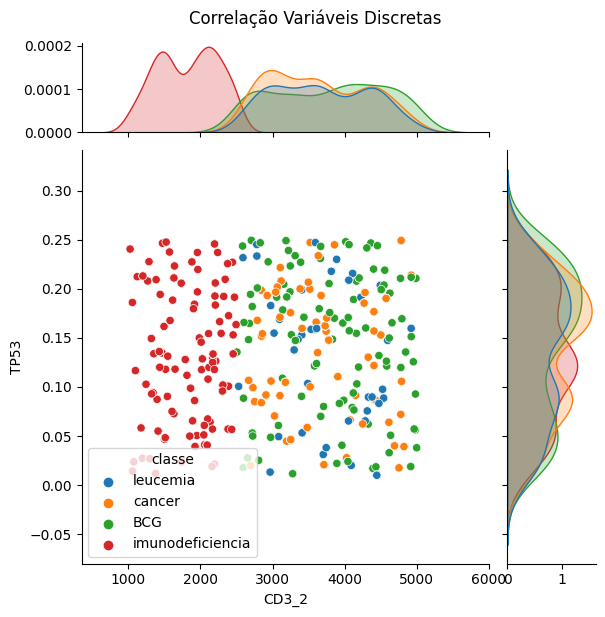

----------


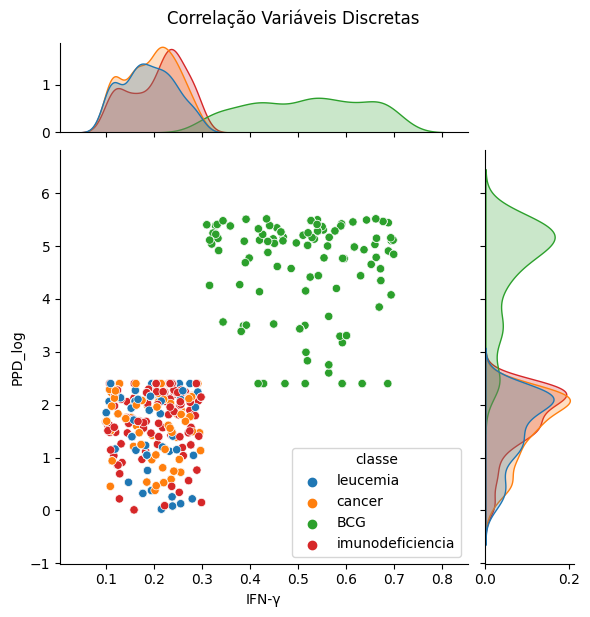

----------


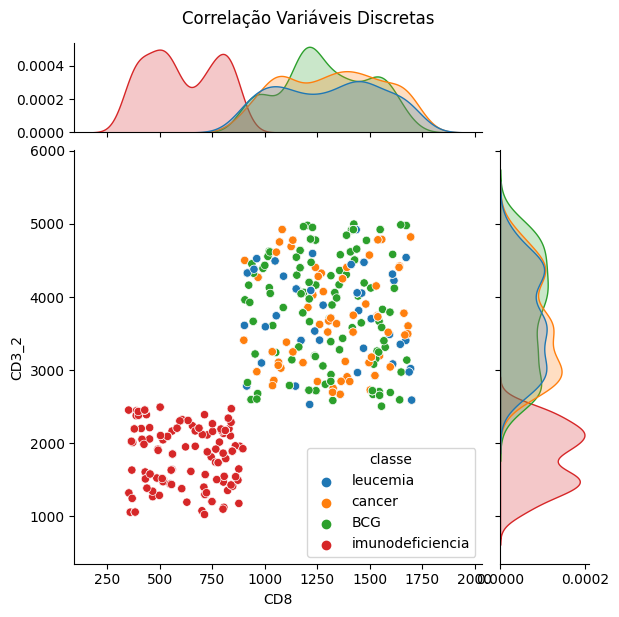

----------


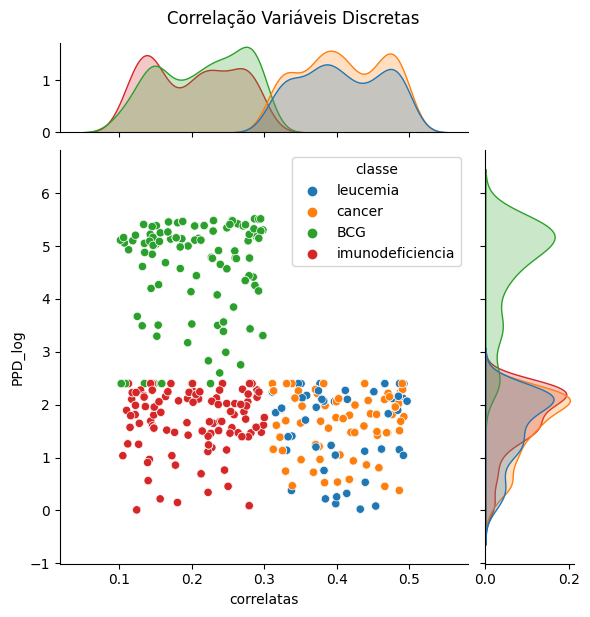

In [5]:
# Gráfico das variáveis que conseguem separar as classes dos daods
for i in enumerate(eixos_graficos):
    print('-'*10)
    c1 = i[1][0]
    c2 = i[1][1]
    p = sns.jointplot(
        x=num_columns[c1],
        y=num_columns[c2],
        hue='classe',
        height=6,
        ratio=4,
        marginal_ticks=True,
        data=df_projeto_float,
    )
    p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
    p.set_axis_labels(
        xlabel=num_columns[c1],
        ylabel=num_columns[c2]
    )
    plt.show()

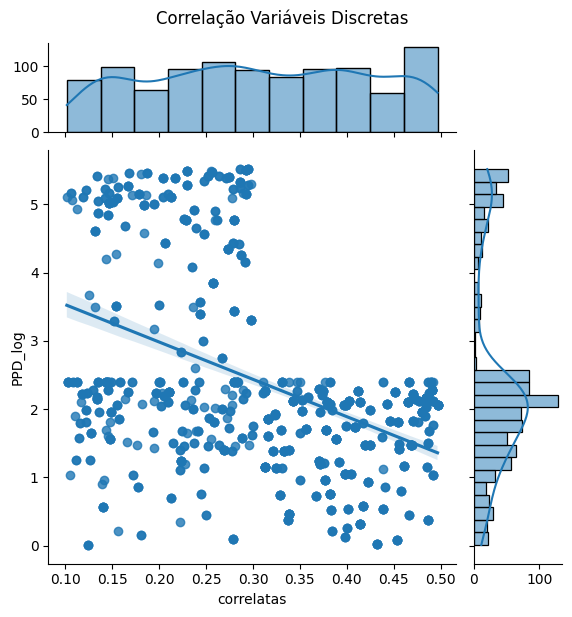

In [6]:
# Grafico de correlação negativa entre os dados
c1 = eixos_graficos[-1][0]
c2 = eixos_graficos[-1][1]
p = sns.jointplot(
    x=num_columns[c1],
    y=num_columns[c2],
    kind='reg',
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_projeto_float,
)
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(
    xlabel=num_columns[c1],
    ylabel=num_columns[c2]
)
plt.show()

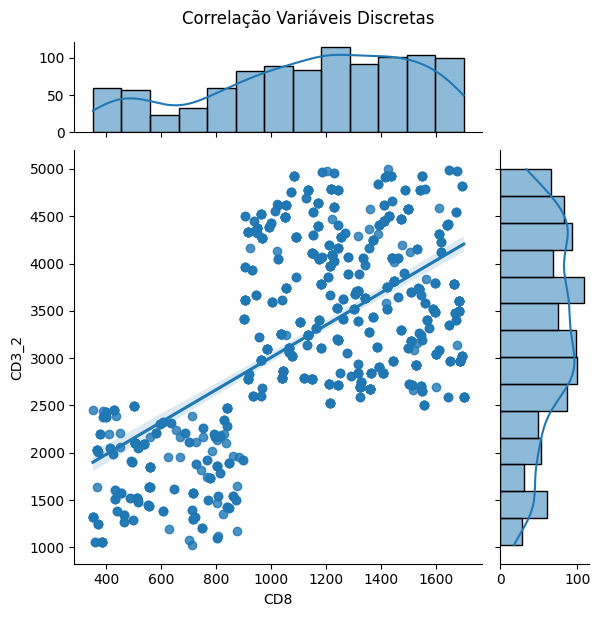

In [7]:
# Gráfico de correlação positiva entre os dados
c1 = eixos_graficos[-2][0]
c2 = eixos_graficos[-2][1]
p = sns.jointplot(
    x=num_columns[c1],
    y=num_columns[c2],
    kind='reg',
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_projeto_float,
)
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(
    xlabel=num_columns[c1],
    ylabel=num_columns[c2]
)
plt.show()

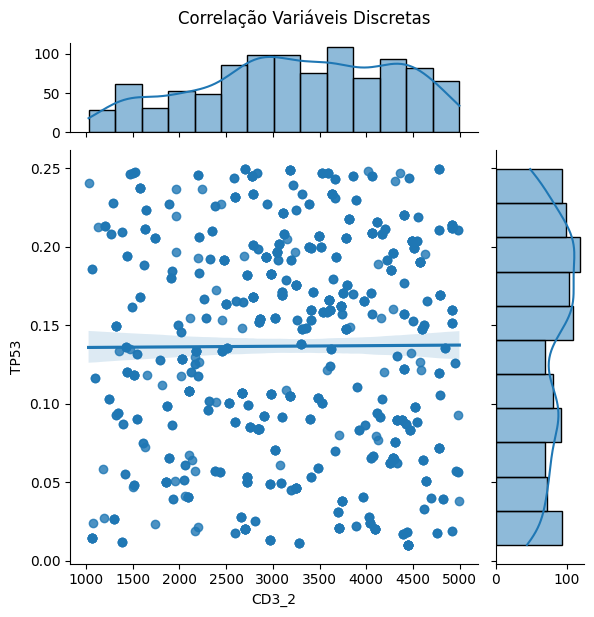

In [8]:
# Gráfico de correlação neutra entre os dados
c1 = eixos_graficos[0][0]
c2 = eixos_graficos[0][1]
p = sns.jointplot(
    x=num_columns[c1],
    y=num_columns[c2],
    kind='reg',
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_projeto_float,
)
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(
    xlabel=num_columns[c1],
    ylabel=num_columns[c2]
)
plt.show()

## Seleção das variáveis qualitativas

In [ ]:
def calcula_indicadores(
        independente: str,
        dependente: str,
        positivo: str,
        negativo: str,
        df: pd.DataFrame,
        categoria: bool = False,
        bins: int = 5,
    ) -> pd.DataFrame:
    '''
        Função para calcular os indicadores de risco, odds, odds ratio,
        log odds e woe para uma variável independente em relação a uma
        variável dependente.
            Parametros:
                independente: str - Nome da variável independente 
                                    (coluna do DataFrame)
                dependente: str - Nome da variável dependente 
                                    (coluna do DataFrame)
                positivo: str - Valor da variável dependente que será
                                considerado como positivo (evento de interesse)
                negativo: str - Valor da variável dependente que será
                                considerado como negativo (evento contrário ao 
                                de interesse)
                df: pd.DataFrame - DataFrame contendo as variáveis
                categoria: bool - Se True, a variável independente será
                                    categorizada em bins (quantis) antes do
                                    cálculo dos indicadores. Default é False.
                bins: int - Número de bins (quantis) para categorizar a 
                            variável independente, caso categoria seja True.
                            Default é 5
            Retorna:
                pd.DataFrame - DataFrame contendo os indicadores calculados 
                para cada categoria da variável independente.
    '''
    if categoria:
        df[independente+"_cat"] = pd.qcut(x=df[independente], q=bins)
        independente += "_cat"
        
    tab = pd.crosstab(df[independente], df[dependente], margins=True)
    odds_all = tab.iloc[2, 1] / tab.iloc[2, 0]
    tab = (
        tab.assign(prob = tab["All"] / tab.loc['All', 'All'])               # Probabilidade de ser mulher ou homem no conjunto de dados
        .assign(risck_event = tab[positivo]/tab['All'])                            # Risco do evento (probabilidede) de uma mulher ou de um homem estar doente
        .assign(odds = tab[positivo] / tab[negativo])                                     # Chance (odds) de uma mulher ou de um homem estar doente
        .assign(odds_ratio = (tab.iloc[:, 1] / tab.iloc[:, 0])/(odds_all))  # A razão entre as chances de estar doente para mulheres e homens
        .assign(log_odd = np.log(tab.loc[:, positivo] / tab.loc[:, negativo]))           # Logaritmo da chance
        .assign(woe = np.log(                                               # Logaritmo da razão da chance ou Weigth of Evidence
            (tab.iloc[:, 1] / tab.iloc[:, 0])/(odds_all)
        ))
    )
    tab['log_odd'] = [x if x != np.inf*-1 else np.nan for x in tab['log_odd']]
    tab['woe'] = [x if x != np.inf*-1 else np.nan for x in tab['woe']]
    
    print(f"Flag {negativo}: {tab.loc['All', negativo]}")
    print(f"Flag {positivo}: {tab.loc['All', positivo]}")
    print(f"Total: {tab.loc['All', 'All']}")

    if categoria:
        df.drop(independente, axis='columns', inplace=True)

    return tab

In [ ]:
df_projeto.select_dtypes(include='object').head()

,IL-2,TNF-α,IgG_1,IgA_1,IgA_2,IgM,FOXP3,classe
0,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
1,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
2,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
3,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia
4,Baixo,Baixo,Alto,Baixo,Alto,Alto,Normal,leucemia


In [11]:
c = 6
positivo = 'BCG'
negativo = 'cancer'
calcula_indicadores(
    independente=df_projeto.select_dtypes(include='object').columns[c],
    dependente='classe',
    positivo=positivo,
    negativo=negativo,
    df=df_projeto.select_dtypes(include='object')
)

Flag cancer: 269
Flag BCG: 264
Total: 1000


classe,BCG,cancer,imunodeficiencia,leucemia,All,prob,risck_event,odds,odds_ratio,log_odd,woe
FOXP3,,,,,,,,,,,
Alterado,0,0,240,0,240,0.24,0.000000,NaN,NaN,NaN,NaN
Normal,264,269,0,227,760,0.76,0.347368,0.981413,1.0,-0.018762,0.0
All,264,269,240,227,1000,1.00,0.264000,0.981413,1.0,-0.018762,0.0


In [12]:
positivo = 'BCG'
negativo = 'imunodeficiencia'
calcula_indicadores(
    independente=df_projeto.select_dtypes(include='object').columns[c],
    dependente='classe',
    positivo=positivo,
    negativo=negativo,
    df=df_projeto.select_dtypes(include='object')
)

Flag imunodeficiencia: 240
Flag BCG: 264
Total: 1000


classe,BCG,cancer,imunodeficiencia,leucemia,All,prob,risck_event,odds,odds_ratio,log_odd,woe
FOXP3,,,,,,,,,,,
Alterado,0,0,240,0,240,0.24,0.000000,0.0,NaN,NaN,NaN
Normal,264,269,0,227,760,0.76,0.347368,inf,1.0,inf,0.0
All,264,269,240,227,1000,1.00,0.264000,1.1,1.0,0.09531,0.0


In [13]:
positivo = 'BCG'
negativo = 'leucemia'
calcula_indicadores(
    independente=df_projeto.select_dtypes(include='object').columns[c],
    dependente='classe',
    positivo=positivo,
    negativo=negativo,
    df=df_projeto.select_dtypes(include='object')
)

Flag leucemia: 227
Flag BCG: 264
Total: 1000


classe,BCG,cancer,imunodeficiencia,leucemia,All,prob,risck_event,odds,odds_ratio,log_odd,woe
FOXP3,,,,,,,,,,,
Alterado,0,0,240,0,240,0.24,0.000000,NaN,NaN,NaN,NaN
Normal,264,269,0,227,760,0.76,0.347368,1.162996,1.0,0.150999,0.0
All,264,269,240,227,1000,1.00,0.264000,1.162996,1.0,0.150999,0.0


In [14]:
positivo = 'cancer'
negativo = 'imunodeficiencia'
calcula_indicadores(
    independente=df_projeto.select_dtypes(include='object').columns[c],
    dependente='classe',
    positivo=positivo,
    negativo=negativo,
    df=df_projeto.select_dtypes(include='object')
)

Flag imunodeficiencia: 240
Flag cancer: 269
Total: 1000


classe,BCG,cancer,imunodeficiencia,leucemia,All,prob,risck_event,odds,odds_ratio,log_odd,woe
FOXP3,,,,,,,,,,,
Alterado,0,0,240,0,240,0.24,0.000000,0.000000,NaN,NaN,NaN
Normal,264,269,0,227,760,0.76,0.353947,inf,1.0,inf,0.0
All,264,269,240,227,1000,1.00,0.269000,1.120833,1.0,0.114072,0.0


In [15]:
positivo = 'cancer'
negativo = 'leucemia'
calcula_indicadores(
    independente=df_projeto.select_dtypes(include='object').columns[c],
    dependente='classe',
    positivo=positivo,
    negativo=negativo,
    df=df_projeto.select_dtypes(include='object')
)

Flag leucemia: 227
Flag cancer: 269
Total: 1000


classe,BCG,cancer,imunodeficiencia,leucemia,All,prob,risck_event,odds,odds_ratio,log_odd,woe
FOXP3,,,,,,,,,,,
Alterado,0,0,240,0,240,0.24,0.000000,NaN,NaN,NaN,NaN
Normal,264,269,0,227,760,0.76,0.353947,1.185022,1.0,0.169761,0.0
All,264,269,240,227,1000,1.00,0.269000,1.185022,1.0,0.169761,0.0


In [16]:
positivo = 'imunodeficiencia'
negativo = 'leucemia'
calcula_indicadores(
    independente=df_projeto.select_dtypes(include='object').columns[c],
    dependente='classe',
    positivo=positivo,
    negativo=negativo,
    df=df_projeto.select_dtypes(include='object')
)

Flag leucemia: 227
Flag imunodeficiencia: 240
Total: 1000


classe,BCG,cancer,imunodeficiencia,leucemia,All,prob,risck_event,odds,odds_ratio,log_odd,woe
FOXP3,,,,,,,,,,,
Alterado,0,0,240,0,240,0.24,1.00,inf,NaN,inf,NaN
Normal,264,269,0,227,760,0.76,0.00,0.000000,1.0,NaN,0.0
All,264,269,240,227,1000,1.00,0.24,1.057269,1.0,0.055689,0.0


In [17]:
coluna = np.random.randint(0, 7, size=1)[0]
df_selecionadas = pd.concat([
                        df_projeto_float,
                        (
                            df_projeto.select_dtypes(include='object')
                            .iloc[:, coluna]
                            .to_frame()
                        )
                    ],
                    axis=1)
df_selecionadas.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,classe,FOXP3
0,0.072077,0.236097,4777.735596,1133.778616,0.588027,0.417118,leucemia,Normal
1,0.099415,0.195858,2728.722124,1502.023593,2.400111,0.350616,leucemia,Normal
2,0.206770,0.210132,3496.556667,1680.599418,2.057824,0.399385,leucemia,Normal
3,0.087026,0.111679,4422.935251,1641.341596,2.230950,0.487439,leucemia,Normal
4,0.154890,0.238945,3021.382901,1694.129006,0.083765,0.453555,leucemia,Normal


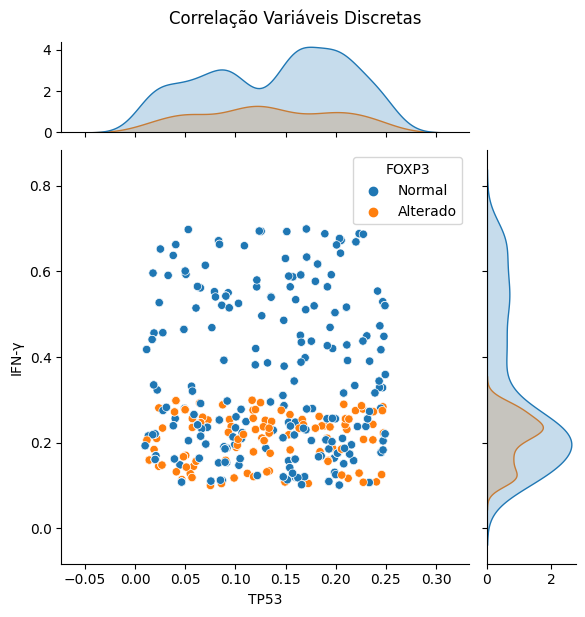

In [18]:
# Gráfico de correlação neutra entre os dados
c1 = 'TP53'
c2 = 'IFN-γ'
p = sns.jointplot(
    x=c1,
    y=c2,
    hue=df_selecionadas.columns[-1],
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_selecionadas,
)
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(
    xlabel=c1,
    ylabel=c2
)
plt.show()

In [19]:
X_train, y_train, X_valid, y_valid, X_test, y_test = train_valid_test_split(
    df_selecionadas,
    target='classe', 
    train_size=0.7, 
    valid_size=0.2, 
    test_size=0.1, 
    random_state=42
)

print('-'*10)
print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"X_test: {X_test.shape}")
print('-'*10)
print(f"y_train: {y_train.shape}")
print(f"y_valid: {y_valid.shape}")
print(f"y_test: {y_test.shape}")

----------
X_train: (700, 7)
X_valid: (200, 7)
X_test: (100, 7)
----------
y_train: (700,)
y_valid: (200,)
y_test: (100,)


In [20]:
y_train.head()

541    imunodeficiencia
440    imunodeficiencia
482            leucemia
422    imunodeficiencia
778            leucemia
Name: classe, dtype: object

In [21]:
dump(X_train, "./data/df_estruturada/08_aula_09_X_train")
dump(X_valid, "./data/df_estruturada/08_aula_09_X_valid")
dump(X_test, "./data/df_estruturada/08_aula_09_X_test")

dump(y_train, "./data/df_estruturada/08_aula_09_y_train")
dump(y_valid, "./data/df_estruturada/08_aula_09_y_valid")
dump(y_test, "./data/df_estruturada/08_aula_09_y_test")

df_X = load("./data/df_estruturada/08_aula_09_X_train")
df_y = load("./data/df_estruturada/08_aula_09_y_train")
df_X.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal


In [22]:
df = pd.concat([df_X, df_y], axis=1)
df.head()

,TP53,IFN-γ,CD3_2,CD8,PPD_log,correlatas,FOXP3,classe
541,0.060824,0.156681,2054.750574,416.256426,1.728509,0.274165,Alterado,imunodeficiencia
440,0.049927,0.277029,1853.437984,561.318387,1.240507,0.222972,Alterado,imunodeficiencia
482,0.020794,0.169621,3712.239299,1314.103239,1.470395,0.468595,Normal,leucemia
422,0.098734,0.117708,1864.705992,802.282545,1.574182,0.288605,Alterado,imunodeficiencia
778,0.193195,0.109547,2926.017038,1524.468444,2.400111,0.466135,Normal,leucemia


In [23]:
os.listdir("./data/df_estruturada")

['08_aula_09_X_test',
 '08_aula_09_X_train',
 '08_aula_09_X_valid',
 '08_aula_09_y_test',
 '08_aula_09_y_train',
 '08_aula_09_y_valid']